Hypothesis Creation and Testing:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

project_root = Path.cwd().parent.parent
df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (122082, 61)


,Sustainability_Score,Total_Renewal_Score_New,Auto_Renewal_Score,Anchoring_Score,Tenure_Scores,Payment_Timeframe,Proforma_Account_Stage,Proforma_Audit_Status,Renewal_Score_At_Release,Proforma_Membership_Status,...,cc_pricing_index,cc_engagement_index,cc_sentiment_score_avg,ren_complaint_index,ren_price_sensitivity,ren_competitor_threat,ren_has_churn_reason,has_auto_renewal,has_worldpay_token,total_interaction_count
0,8.0,42.5,9,7.5,9.0,0.0,Published,Accredited,26.0,Accredited,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0,1,1,0
1,8.0,41.5,9,7.5,8.0,0.0,Published,Accredited,24.5,Accredited,...,0.0,0.166667,85.000000,0.000000,0.0,0.0,0,1,1,4
2,8.0,33.0,8,7.5,9.5,0.0,Membership Only,Failed- Renewal Questionnaire not received,24.0,Member Only,...,0.0,0.000000,0.000000,0.166667,0.0,0.0,0,0,1,4
3,9.5,44.5,9,7.5,9.5,0.0,Renewal Process,Renewal Questionnaire Sent,27.0,Accredited,...,0.0,0.194444,73.333333,0.000000,0.0,0.0,0,1,1,10
4,9.5,42.5,9,7.5,8.5,0.0,Published,Accredited,26.0,Accredited,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0,1,1,0


 Hypothesis 1: Impact of Renewal Friction on Prospect Outcome
 

Null Hypothesis (H0): There is no significant relationship between the mean renewal friction score ren_friction_score_mean and the prospect outcome. The friction experienced during the renewal process is similar for both renewed and churned customers.

Alternative Hypothesis (H1): Customers who end up churning have a significantly higher mean renewal friction score compared to those who renew. Higher friction during the renewal process negatively impacts the prospect_outcome.

T-Test 

Mean Friction (Renewed): 0.33
Mean Friction (Churned): 0.14


C:\Users\ShefaliChopra\AppData\Local\Temp\ipykernel_6444\1047700783.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prospect_Outcome', y='ren_friction_score_mean', data=df, palette='viridis')


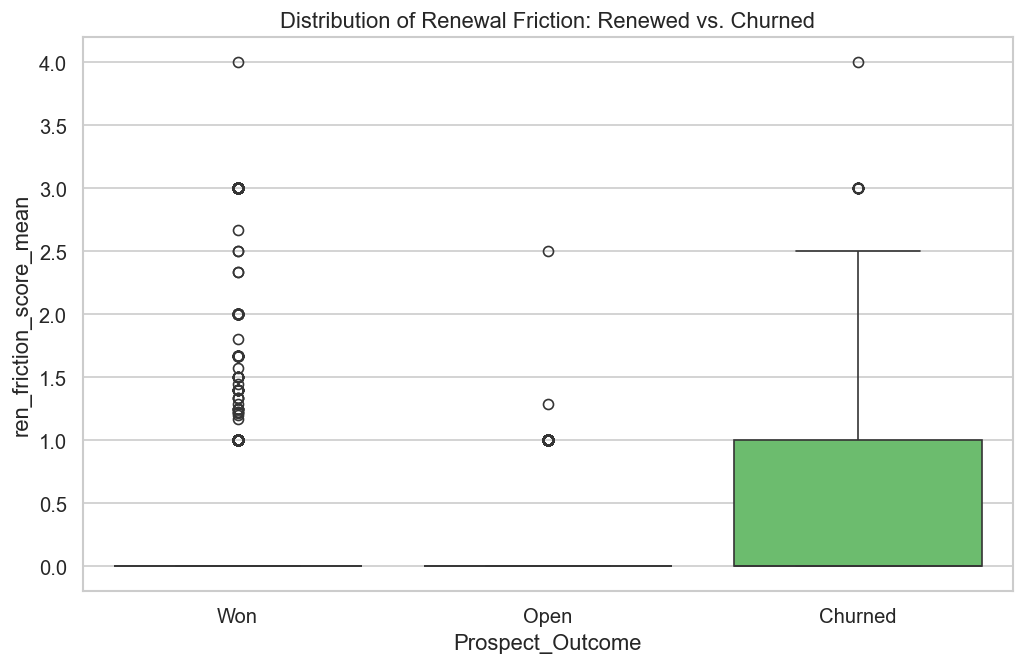


Levene’s Test p-value: 0.0000

--- HYPOTHESIS TEST RESULTS ---
Welch’s T-Test p-value: 0.0000000000
Mann-Whitney U p-value: 1.0000000000

Result: REJECT the Null Hypothesis.
Conclusion: There is a statistically significant difference in friction scores.
The friction experienced by churned customers is significantly higher.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Prepare the two groups
renewed = df[df['Prospect_Outcome'] == 'Won']['ren_friction_score_mean']
churned = df[df['Prospect_Outcome'] == 'Churned']['ren_friction_score_mean']

print(f"Mean Friction (Renewed): {renewed.mean():.2f}")
print(f"Mean Friction (Churned): {churned.mean():.2f}")

# 2. Visualize the difference (Vital for Interpretation)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Prospect_Outcome', y='ren_friction_score_mean', data=df, palette='viridis')
plt.title('Distribution of Renewal Friction: Renewed vs. Churned')
plt.show()

# 3. Check for Equal Variance (Levene's Test)
stat_var, p_var = stats.levene(renewed, churned)
print(f"\nLevene’s Test p-value: {p_var:.4f}")

# 4. Perform the T-Test (Welch's T-Test)
t_stat, t_p_val = stats.ttest_ind(churned, renewed, equal_var=False)

# 5. Perform Mann-Whitney U Test (Robust Fallback)
u_stat, u_p_val = stats.mannwhitneyu(churned, renewed, alternative='greater')

# Interpretation 
print("\n--- HYPOTHESIS TEST RESULTS ---")
print(f"Welch’s T-Test p-value: {t_p_val:.10f}")
print(f"Mann-Whitney U p-value: {u_p_val:.10f}")

if t_p_val < 0.05:
    print("\nResult: REJECT the Null Hypothesis.")
    print("Conclusion: There is a statistically significant difference in friction scores.")
    print("The friction experienced by churned customers is significantly higher.")
else:
    print("\nResult: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: Friction scores do not show a statistically significant relationship with churn.")

Hypothesis 2:  Impact of Logged Churn Reasons on Prospect Outcome

Null Hypothesis (H0): The presence of a logged churn reason during renewal interactions ren_has_churn_reason is independent of the final prospect_outcome. Having a recorded churn reason does not significantly alter the likelihood of a customer churning.


Alternative Hypothesis (H1): There is a significant association between having a logged churn reason and the prospect_outcome. Specifically, prospects with a recorded churn reason ren_has_churn_reason = 1 are proportionally more likely to churn compared to those without one.

--- Contingency Table ---
Prospect_Outcome      Churned  Open     Won
ren_has_churn_reason                       
0                       12001  8183  100962
1                         667     5     264


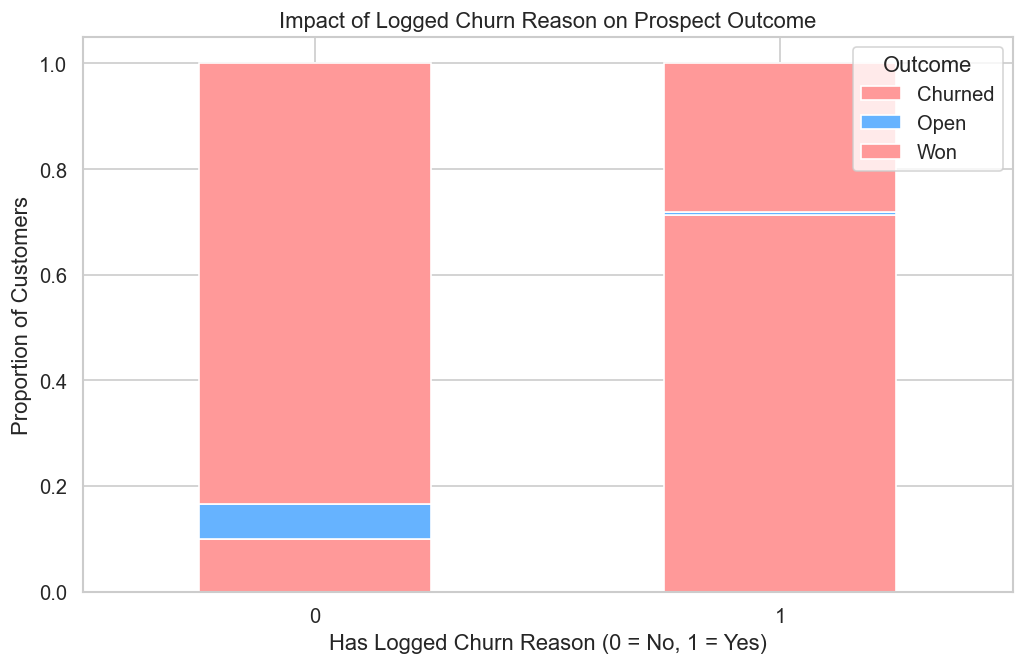


--- CHI-SQUARE TEST RESULTS ---
Chi-Square Statistic: 3763.6257
p-value: 0.0000000000

Result: REJECT the Null Hypothesis (H0).
Conclusion: There is a significant association between logging a churn reason and the outcome.
Recording a churn reason is a strong indicator of the final outcome.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Create a Contingency Table (Cross-tabulation)
contingency_table = pd.crosstab(df['ren_has_churn_reason'], df['Prospect_Outcome'])

print("--- Contingency Table ---")
print(contingency_table)

# 2. Perform the Chi-Square Test
# chi2: The test statistic
# p: The p-value
# dof: Degrees of freedom
# expected: The frequencies expected if there was NO relationship
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 3. Visualization: Proportional Stacked Bar Chart
props = contingency_table.div(contingency_table.sum(axis=1), axis=0)

props.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999','#66b3ff'])
plt.title('Impact of Logged Churn Reason on Prospect Outcome')
plt.xlabel('Has Logged Churn Reason (0 = No, 1 = Yes)')
plt.ylabel('Proportion of Customers')
plt.legend(title='Outcome', loc='upper right')
plt.xticks(rotation=0)
plt.show()

# 4. Interpretation
print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.10f}")

if p < 0.05:
    print("\nResult: REJECT the Null Hypothesis (H0).")
    print("Conclusion: There is a significant association between logging a churn reason and the outcome.")
    print("Recording a churn reason is a strong indicator of the final outcome.")
else:
    print("\nResult: FAIL TO REJECT the Null Hypothesis (H0).")
    print("Conclusion: There is no significant association. Logging a reason doesn't appear to change the odds.")

In [ ]:
import numpy as np

# 1. Get the raw numbers from your contingency table
table = pd.crosstab(df['ren_has_churn_reason'], df['Prospect_Outcome'])

# Extract values for calculation
# Let's assume table looks like this:
# Outcome:    Lost (Churn)   Won (Renewed)
# Reason 0:      a               b
# Reason 1:      c               d

a = table.loc[0, 'Churned']
b = table.loc[0, 'Won']
c = table.loc[1, 'Churned']
d = table.loc[1, 'Won']

# 2. Calculate Odds Ratio
# (Odds of churning with a reason) / (Odds of churning without a reason)
odds_ratio = (c / d) / (a / b)

# 3. Calculate Relative Risk (Risk Ratio)
# (Probability of churning with a reason) / (Probability of churning without a reason)
risk_ratio = (c / (c + d)) / (a / (a + b))

print(f"--- RISK QUANTIFICATION ---")
print(f"Odds Ratio: {odds_ratio:.2f}")
print(f"Risk Ratio: {risk_ratio:.2f}")
print(f"\nInterpretation: A customer with a logged churn reason is {risk_ratio:.1f}x more likely to churn.")

--- RISK QUANTIFICATION ---
Odds Ratio: 21.26
Risk Ratio: 6.74

Interpretation: A customer with a logged churn reason is 6.7x more likely to churn.


Hypothesis 3: Impact of Competitor Threat on Prospect Outcome

Null Hypothesis (H0): There is no significant difference in the competitor threat score ren_competitor_threat between the different prospect outcomes. A higher perceived competitor threat does not impact the likelihood of a customer churning.

Alternative Hypothesis (H1): Customers who churn have a significantly higher competitor threat score compared to those who renew. High mentions or indications of competitors during the renewal process are a predictor of churn.

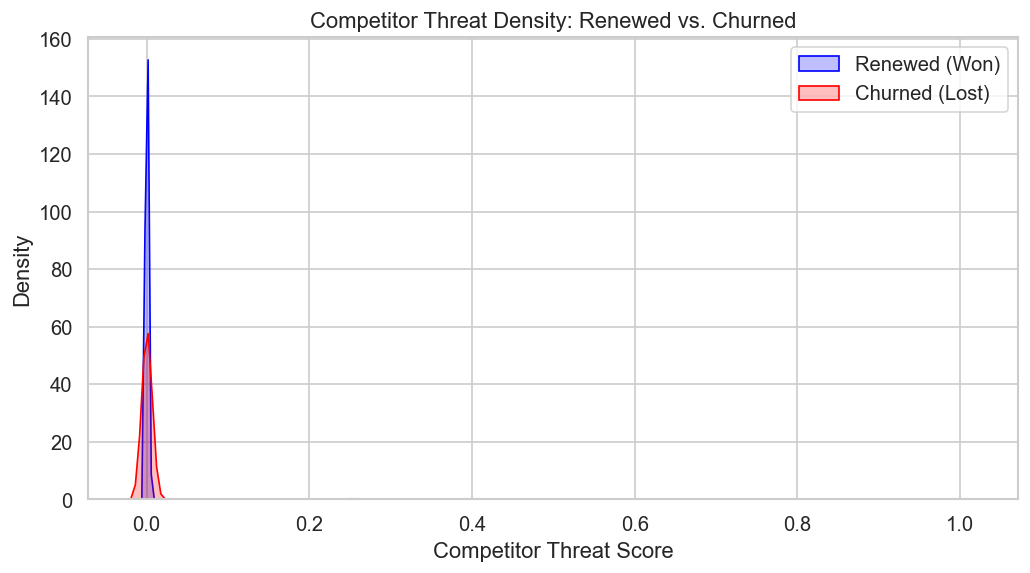

--- HYPOTHESIS 3 RESULTS ---
Mean Threat (Renewed): 0.0015
Mean Threat (Churned): 0.0061
Welch’s T-Test p-value: 0.0000000000
Mann-Whitney U p-value: 0.0000000000

Result: REJECT the Null Hypothesis.
Conclusion: Churned customers have a significantly higher perceived competitor threat.
Competitor mentions are a reliable leading indicator of churn.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


def calculate_threat(row):
    score = 0
    if row.get('Explicit_Competitor_Mention') == 'Yes': score += 2
    if row.get('Price_Switching_Mentioned') == 'Yes': score += 2
    if row.get('Explicit_Switching_Intent') == 'Yes': score += 3
    if row.get('Mentioned_Competitors') == 'Yes': score += 1
    return score


if 'ren_competitor_threat' not in df.columns:
    df['ren_competitor_threat'] = df.apply(calculate_threat, axis=1)


renewed_threat = df[df['Prospect_Outcome'] == 'Won']['ren_competitor_threat']
churned_threat = df[df['Prospect_Outcome'] == 'Churned']['ren_competitor_threat']


plt.figure(figsize=(10, 5))
sns.kdeplot(renewed_threat, label='Renewed (Won)', fill=True, color='blue')
sns.kdeplot(churned_threat, label='Churned (Lost)', fill=True, color='red')
plt.title('Competitor Threat Density: Renewed vs. Churned')
plt.xlabel('Competitor Threat Score')
plt.legend()
plt.show()

# Welch's T-Test (Handles unequal variances)
t_stat, t_p = stats.ttest_ind(churned_threat, renewed_threat, equal_var=False)

# Mann-Whitney U (Handles non-normal/skewed data)
u_stat, u_p = stats.mannwhitneyu(churned_threat, renewed_threat, alternative='greater')

# Interpretation
print("--- HYPOTHESIS 3 RESULTS ---")
print(f"Mean Threat (Renewed): {renewed_threat.mean():.4f}")
print(f"Mean Threat (Churned): {churned_threat.mean():.4f}")
print(f"Welch’s T-Test p-value: {t_p:.10f}")
print(f"Mann-Whitney U p-value: {u_p:.10f}")

if u_p < 0.05:
    print("\nResult: REJECT the Null Hypothesis.")
    print("Conclusion: Churned customers have a significantly higher perceived competitor threat.")
    print("Competitor mentions are a reliable leading indicator of churn.")
else:
    print("\nResult: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: Perceived competitor threat does not appear to differ significantly between groups.")

Hypothesis 4:  Impact of Price Sensitivity on Prospect Outcome

Null Hypothesis (H0): There is no significant difference in the price sensitivity score ren_price_sensitivity between the varying prospect outcomes. Price sensitivity expressed during the renewal process does not predict whether a customer churns.

Alternative Hypothesis (H1): Customers who end up churning display a significantly higher price sensitivity score compared to those who renew. High sensitivity to price and pricing friction is a strong indicator of impending churn.

In [ ]:
import pandas as pd
from scipy import stats

# Filter data into the two groups
renewed = df[df['Prospect_Outcome'] == 'Won']['ren_price_sensitivity']
churned = df[df['Prospect_Outcome'] == 'Churned']['ren_price_sensitivity']

# Descriptive Statistics
mean_ren = renewed.mean()
mean_chu = churned.mean()

# Run Welch's T-Test (equal_var=False)
t_stat, p_val = stats.ttest_ind(renewed, churned, equal_var=False)

# Output
print(f"--- HYPOTHESIS 4 RESULTS ---")
print(f"Mean Price Sensitivity (Renewed): {mean_ren:.4f}")
print(f"Mean Price Sensitivity (Churned): {mean_chu:.4f}")
print(f"Welch’s T-Test p-value: {p_val:.10f}")

if p_val < 0.05:
    print("Result: REJECT the Null Hypothesis.")
    print("Conclusion: Churned customers display significantly higher price sensitivity.")
else:
    print("Result: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: No significant difference in price sensitivity between groups.")

--- HYPOTHESIS 4 RESULTS ---
Mean Price Sensitivity (Renewed): 0.0055
Mean Price Sensitivity (Churned): 0.0173
Welch’s T-Test p-value: 0.0000000000
Result: REJECT the Null Hypothesis.
Conclusion: Churned customers display significantly higher price sensitivity.


Hypothesis 5: Impact of Renewal Score at Release on Prospect Outcome

Null Hypothesis (H0): There is no significant difference in the mean Renewal_Score_At_Release between customers who churn and customers who renew. The baseline renewal score given at the release of the renewal does not help predict the final outcome.

Alternative Hypothesis (H1): There is a statistically significant difference in the mean Renewal_Score_At_Release based on prospect outcome. Customers who successfully renew generally have a higher starting renewal score at release compared to those who end up churning.

In [ ]:
import pandas as pd
from scipy import stats

# 1. Segregate the groups
group_renewed = df[df['Prospect_Outcome'] == 'Won']['Renewal_Score_At_Release']
group_churned = df[df['Prospect_Outcome'] == 'Churned']['Renewal_Score_At_Release']

# 2. Basic Statistics for context
mean_ren = group_renewed.mean()
mean_chu = group_churned.mean()
std_ren = group_renewed.std()
std_chu = group_churned.std()

# 3. Perform Welch's T-Test
t_stat, p_val = stats.ttest_ind(group_renewed, group_churned, equal_var=False)

# 4. Results
print(f"--- HYPOTHESIS 5 RESULTS ---")
print(f"Mean Score (Renewed): {mean_ren:.4f} (±{std_ren:.4f})")
print(f"Mean Score (Churned): {mean_chu:.4f} (±{std_chu:.4f})")
print(f"Welch’s T-Test p-value: {p_val:.10f}")

if p_val < 0.05:
    print("Result: REJECT the Null Hypothesis.")
    print("Conclusion: The baseline Renewal Score is a significant predictor of the outcome.")
else:
    print("Result: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: The starting Renewal Score shows no significant difference between groups.")

--- HYPOTHESIS 5 RESULTS ---
Mean Score (Renewed): 25.9854 (±1.7708)
Mean Score (Churned): 24.0944 (±1.9316)
Welch’s T-Test p-value: 0.0000000000
Result: REJECT the Null Hypothesis.
Conclusion: The baseline Renewal Score is a significant predictor of the outcome.


Conclusion

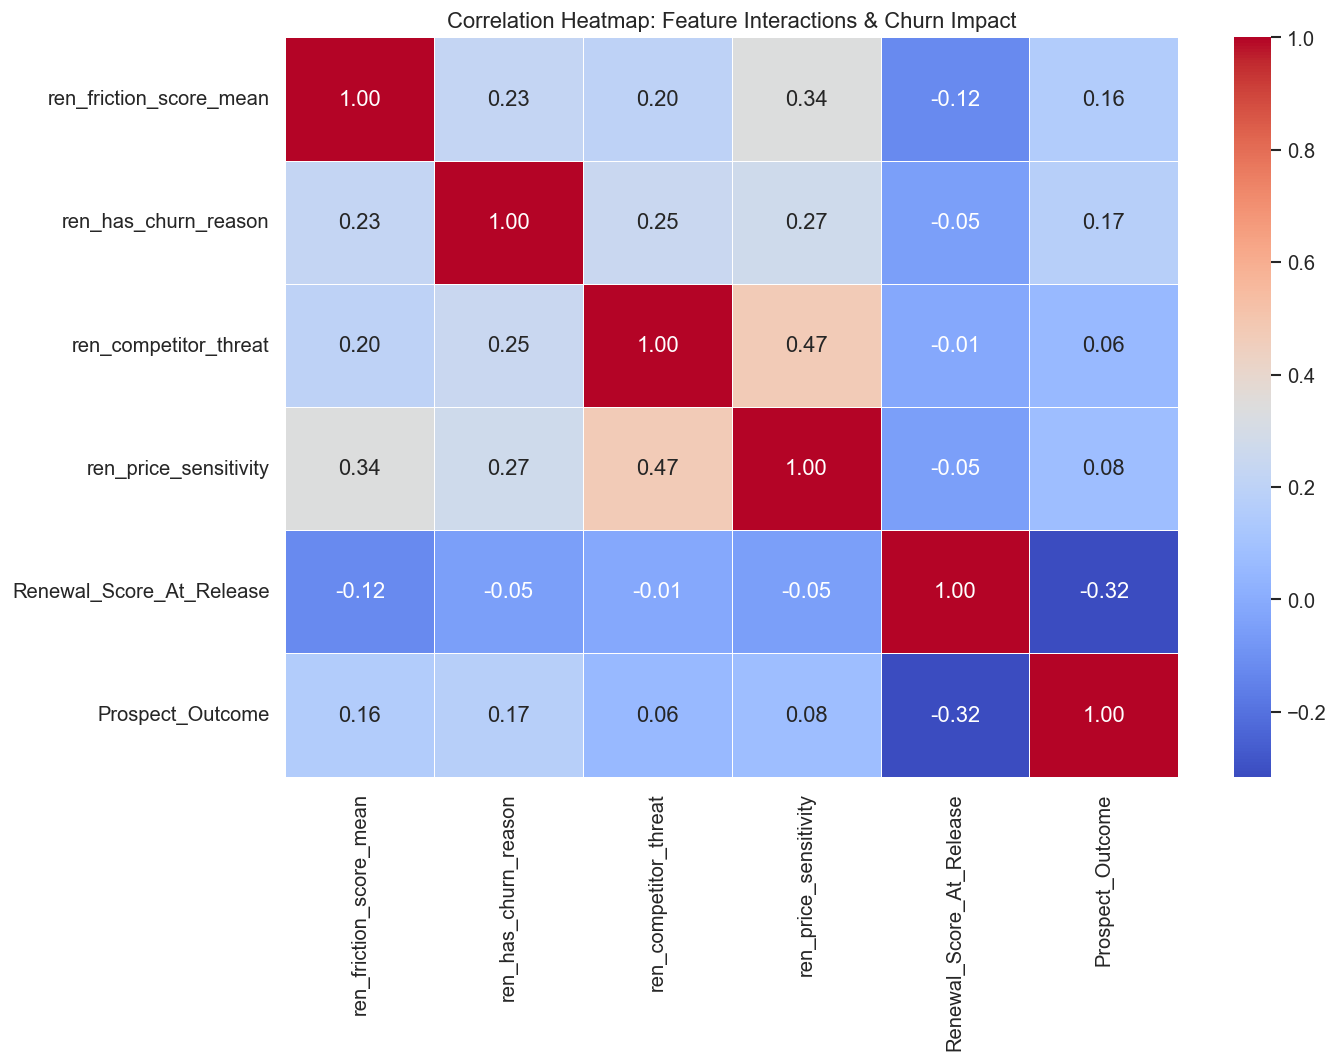

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_check = [
    'ren_friction_score_mean',    # Hypothesis 1
    'ren_has_churn_reason',      # Hypothesis 2
    'ren_competitor_threat',     # Hypothesis 3
    'ren_price_sensitivity',     # Hypothesis 4
    'Renewal_Score_At_Release'   # Hypothesis 5
]


corr_df = df[features_to_check + ['Prospect_Outcome']].copy()
corr_df['Prospect_Outcome'] = corr_df['Prospect_Outcome'].map({'Won': 0, 'Churned': 1})

plt.figure(figsize=(12, 8))
correlation_matrix = corr_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Feature Interactions & Churn Impact')
plt.show()

The hypothesis testing confirms that renewal interactions are highly predictive of the final prospect outcome. Customers who ultimately churn experience a statistically significant higher level of friction during their renewal process compared to those who renew. Furthermore, explicitly logging a churn reason during these interactions is a critical warning sign; customers with a logged reason are nearly 7 times more likely to churn, indicating these renewal metrics should be highly prioritized features in the final prediction model.